In [24]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, log_loss
import matplotlib.pyplot as plt

$$
G_i=1-\sum_{k=1}^n p_{i,k}^2
$$

In [16]:
n_patients = 60
n_healthy = 240

def calc_gini(data):
    return 1 - ((data / sum(data))**2).sum()
    
data = np.array([n_patients, n_healthy])
calc_gini(data)

np.float64(0.31999999999999984)

$$
H_i=-\sum_{k=1, p_{i,k}\neq 0}^{n} p_{i,k}\log_2(p_{i,k})
$$

In [17]:
def calc_enthropy(data):
    probas = data / data.sum()
    enthropy = -(probas * np.log2(probas)).sum()
    return enthropy

calc_enthropy(data)

np.float64(0.7219280948873623)

$$
J(k,t_k)=\frac{m_{\text{left}}}{m}G_{\text{left}} + \frac{m_{\text{right}}}{m}G_{\text{right}}
$$

In [20]:
n_healty_left = 180
n_patient_left = 10

n_healthy_right = 60
n_patient_right = 50

left = np.array([n_healty_left, n_patient_left])
right = np.array([n_healthy_right, n_patient_right])

m = left.sum() + right.sum()

J = (left.sum()/m) * calc_gini(left) + (right.sum()/m) * calc_gini(right)
J

np.float64(0.24497607655502407)

$$
IG=H(\text{parent})−(\frac{m_{\text{left}}}{m}H_{\text{left}}+\frac{m_{\text{right}}}{m}H_{\text{right}})
$$

In [22]:
IG = calc_enthropy(data) - \
    ((left.sum()/m) * calc_enthropy(left) + (right.sum()/m) * calc_enthropy(right))
IG

np.float64(0.16905125969692825)

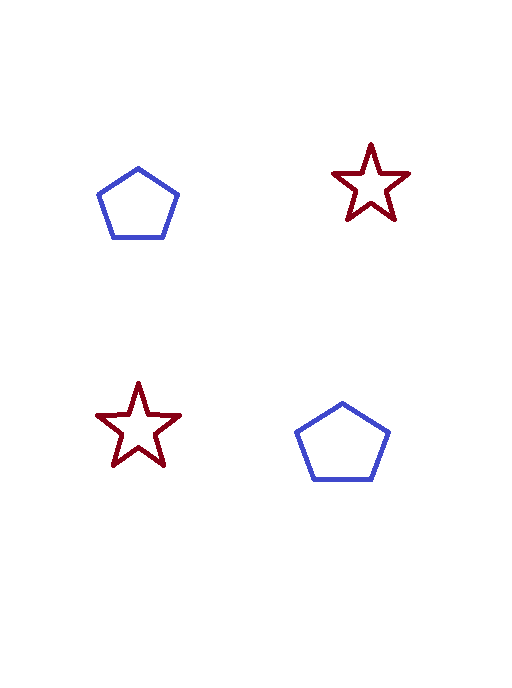

درخت تصمیم با رسم خط عمودی هر بار فضا را به زیر فضا تقسیم میکند تا ناخالصی را کاهش دهد. برای مثال یک ویژگی را انتخاب میکند و بر اساس ترشولد تصمیم میگیرد.
     حال که زیر فضای جدید  به دست امد دوباره بر اساس یک فیچر جدید فضا را تقسیم میکند به طوری که در زیر فضای نهایی، هر قسمت تنها شامل نمونه هایی از یک کلاس باشند.

In [25]:
df = pd.read_csv("./datasets/titanic.csv")
df = df[['Fare', 'Age', 'Sex', 'Pclass', 'Survived']]
df.head()

,Fare,Age,Sex,Pclass,Survived
0,7.2500,22.0,male,3,0
1,71.2833,38.0,female,1,1
2,7.9250,26.0,female,3,1
3,53.1000,35.0,female,1,1
4,8.0500,35.0,male,3,0


In [26]:
X = df[['Fare', 'Age', 'Sex', 'Pclass']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

In [28]:
num_attribs = ['Fare', 'Age', 'Pclass']
cat_attribs = ["Sex"]

num_pipeline = make_pipeline(
    SimpleImputer(strategy="mean"))

cat_pipeline = make_pipeline(
    OneHotEncoder(handle_unknown="ignore")
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

preprocessing

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [31]:
dt_clf = make_pipeline(preprocessing, DecisionTreeClassifier(max_depth=4))

dt_clf.fit(X_train, y_train)
print(f"model acc: {dt_clf.score(X_test, y_test)}")

model acc: 0.7872340425531915


In [38]:
model = dt_clf[1]
feature_importance = pd.DataFrame(
    {
        "importance": model.feature_importances_
    },
    index=dt_clf.named_steps["columntransformer"].get_feature_names_out()
)

feature_importance = feature_importance.sort_values(
    by="importance", ascending=False
)

feature_importance

,importance
cat__Sex_female,0.559241
num__Fare,0.242474
num__Age,0.121149
num__Pclass,0.077136
cat__Sex_male,0.000000


بلی، برابر است.

In [39]:
df = pd.read_csv('./datasets/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [40]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [44]:
X = df.drop(columns='target')
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [45]:
y = df[['target']]
y.head()

,target
0,1
1,1
2,1
3,1
4,1


In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

In [48]:
dt_clf1 = make_pipeline(SimpleImputer(strategy="mean"), DecisionTreeClassifier())
dt_clf2 = make_pipeline(SimpleImputer(strategy="mean"), DecisionTreeClassifier(min_samples_leaf=20))
dt_clf3 = make_pipeline(SimpleImputer(strategy="mean"), DecisionTreeClassifier(max_leaf_nodes=8))

for clf, name in zip((dt_clf1, dt_clf2, dt_clf3), \
                     ('no_restrictions', 'min_samples_leaf', 'max_leaf_nodes')):
    print(name)
    clf.fit(X_train, y_train)
    print(f"clf.score(X_train, y_train): {clf.score(X_train, y_train)}")
    print(f"clf.score(X_test, y_test): {clf.score(X_test, y_test)}")
    print("*" * 20)
    print()

no_restrictions
clf.score(X_train, y_train): 1.0
clf.score(X_test, y_test): 0.7362637362637363
********************

min_samples_leaf
clf.score(X_train, y_train): 0.8018867924528302
clf.score(X_test, y_test): 0.6923076923076923
********************

max_leaf_nodes
clf.score(X_train, y_train): 0.8773584905660378
clf.score(X_test, y_test): 0.7472527472527473
********************



$dt_1 \rightarrow \quad \text{Overfit}$

$dt_2 \rightarrow  \quad \text{Underfit}$

$dt_3 \rightarrow  \quad \text{Overfit but better than} \quad dt_1$

In [83]:
df = pd.read_csv("./datasets/titanic.csv")
df = df[['Fare', 'Age', 'Sex', 'Pclass', 'Survived']]

X = df[['Fare', 'Age', 'Sex', 'Pclass']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

num_attribs = ['Fare', 'Age', 'Pclass']
cat_attribs = ["Sex"]

num_pipeline = make_pipeline(
    SimpleImputer(strategy="mean"), 
    StandardScaler())

cat_pipeline = make_pipeline(
    OneHotEncoder(handle_unknown="ignore")
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

In [98]:
depths = list(range(1, 11))
scores = []

for depth in depths:
    dt_clf = log_reg = make_pipeline(preprocessing, DecisionTreeClassifier(max_depth=depth))

    dt_clf.fit(X_train, y_train)
    scores.append(dt_clf.score(X_test, y_test))

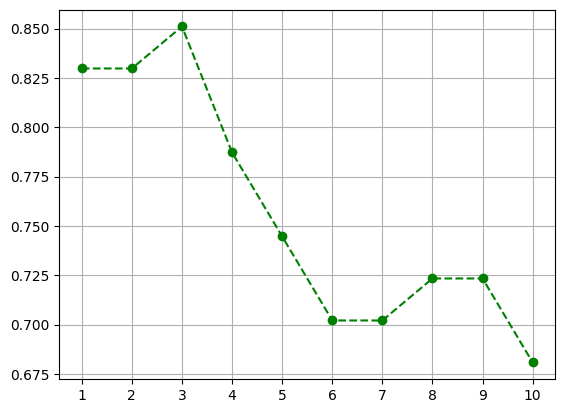

In [99]:
plt.plot(depths, scores, 'go--')
plt.xticks(depths)
plt.grid()
plt.show()

The best depth is 3, after that it starts to wiggling